# 04 · Modelado: peligro sísmico × exposición (CRISP-DM — Fase 4a)

> El presente índice responde a la pregunta «¿en qué cantones es más urgente
> invertir en construcción sismorresistente?» y no a la de la ocurrencia
> temporal de futuros eventos. Constituye una clasificación relativa de
> territorios a partir de sismicidad histórica (peligro) y densidad
> poblacional (exposición); no es un mapa de peligro probabilístico
> normativo, función que corresponde a la zonificación oficial de la
> **NEC-SE-DS**.

Método transparente:
- **Peligro** = ½·frecuencia histórica normalizada + ½·energía liberada
  normalizada, computadas **solo con sismicidad somera (profundidad ≤ 70 km)**:
  los eventos someros son los que gobiernan la sacudida en superficie; la
  energía usa la escala de Gutenberg-Richter (E = 10^(1.5M+4.8) joules).
- **Exposición** = densidad poblacional del Censo 2022 (log-normalizada).
- **Riesgo relativo** = peligro(0–1) × exposición(0–1) × 100.

In [1]:
# --- Configuración común ---
import os
import sys
import pathlib

In [2]:
RAIZ = pathlib.Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ))

In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
FIG = pathlib.Path("reports/figures")

In [5]:
from src.models import indice_peligro, indice_riesgo

In [6]:
base = gpd.read_file("data/processed/cantones_riesgo.geojson")
print(f"Cantones: {len(base)}")

Cantones: 224


In [7]:
# --- Cálculo de los índices ---
base["indice_peligro"] = indice_peligro(base)
base["indice_riesgo"] = indice_riesgo(base["indice_peligro"], base["densidad_hab_km2"])
base[["canton", "provincia", "indice_peligro", "densidad_hab_km2", "indice_riesgo"]].head()

,canton,provincia,indice_peligro,densidad_hab_km2,indice_riesgo
0,24 de Mayo,Manabí,47.90,59.423986,24.69
1,Aguarico,Orellana,39.88,0.611385,2.39
2,Alausi,Chimborazo,42.06,22.344610,16.65
3,Alfredo Baquerizo Moreno,Guayas,0.00,115.925183,0.00
4,Ambato,Tungurahua,36.28,361.760838,26.87


In [8]:
# --- Top 15 cantones por índice de riesgo relativo ---
top = base.nlargest(15, "indice_riesgo")
top[["canton", "provincia", "n_sismos", "mag_max", "indice_peligro",
     "poblacion_2022", "densidad_hab_km2", "indice_riesgo"]].reset_index(drop=True)

,canton,provincia,n_sismos,mag_max,indice_peligro,poblacion_2022,densidad_hab_km2,indice_riesgo
0,Manta,Manabí,36.0,5.7,62.85,271145.0,921.395799,53.93
1,Guayaquil,Guayas,45.0,5.8,62.36,2746403.0,664.462977,50.95
2,Salinas,Santa Elena,13.0,5.2,52.51,86801.0,1221.210820,46.91
3,Quito,Pichincha,19.0,5.3,55.73,2679722.0,632.131574,45.18
4,Montecristi,Manabí,62.0,6.2,72.19,99937.0,131.840531,44.36
5,Esmeraldas,Esmeraldas,43.0,6.3,67.87,211848.0,157.043115,43.19
6,Machala,El Oro,5.0,5.4,46.51,306309.0,940.899833,40.03
7,Santa Rosa,El Oro,47.0,6.3,67.29,80299.0,98.408878,38.90
8,Portoviejo,Manabí,12.0,4.9,50.94,322925.0,333.145056,37.21
9,Duran,Guayas,7.0,5.5,41.19,303910.0,1005.424671,35.79


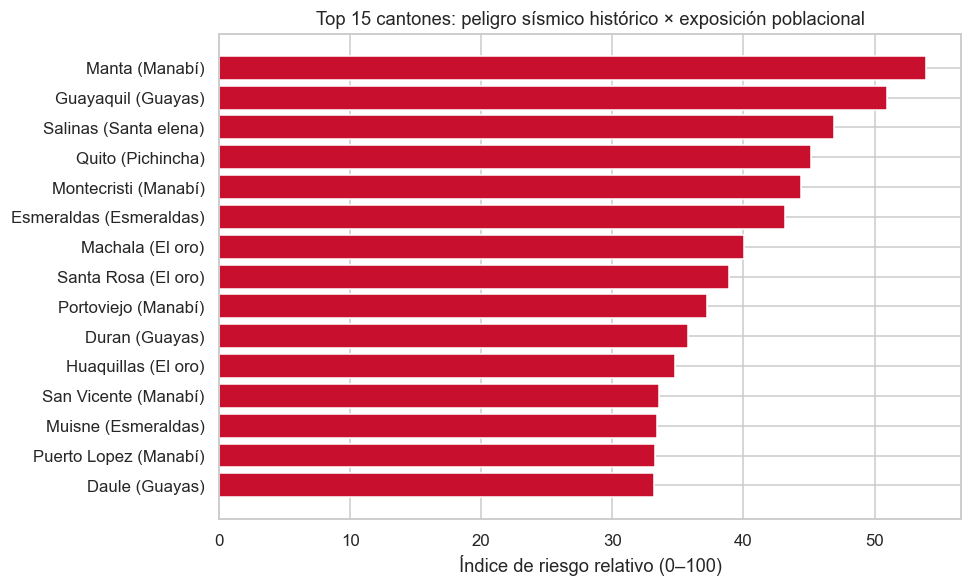

In [9]:
# --- Figura: barras del top 15 ---
fig, eje = plt.subplots(figsize=(9, 5.5))
datos = top.iloc[::-1]
eje.barh(datos["canton"] + " (" + datos["provincia"].str.capitalize() + ")",
         datos["indice_riesgo"], color="#C8102E")
eje.set_xlabel("Índice de riesgo relativo (0–100)")
eje.set_title("Top 15 cantones: peligro sísmico histórico × exposición poblacional")
plt.tight_layout()
plt.savefig(FIG / "04_top15_riesgo.png", bbox_inches="tight")
plt.show()

In [10]:
# --- Mapas coropléticos (Ecuador continental) ---
def mapa_canton(gdf, columna, titulo, cmap="YlOrRd", leyenda=""):
    """Mapa coroplético del Ecuador continental (excluye Galápagos por atributo)."""
    continente = gdf[gdf["provincia"] != "Galápagos"].copy()
    continente[columna] = continente[columna].fillna(0)
    fig, eje = plt.subplots(figsize=(8, 8.5))
    continente.plot(ax=eje, column=columna, cmap=cmap, legend=True,
                    edgecolor="#666666", linewidth=0.2,
                    legend_kwds={"shrink": 0.7})
    eje.set_title(titulo, fontsize=11)
    eje.set_xlabel("Longitud"); eje.set_ylabel("Latitud")
    if leyenda:
        eje.annotate(leyenda, xy=(0.02, 0.02), xycoords="axes fraction", fontsize=8, color="#333333")
    plt.tight_layout()
    return fig, eje

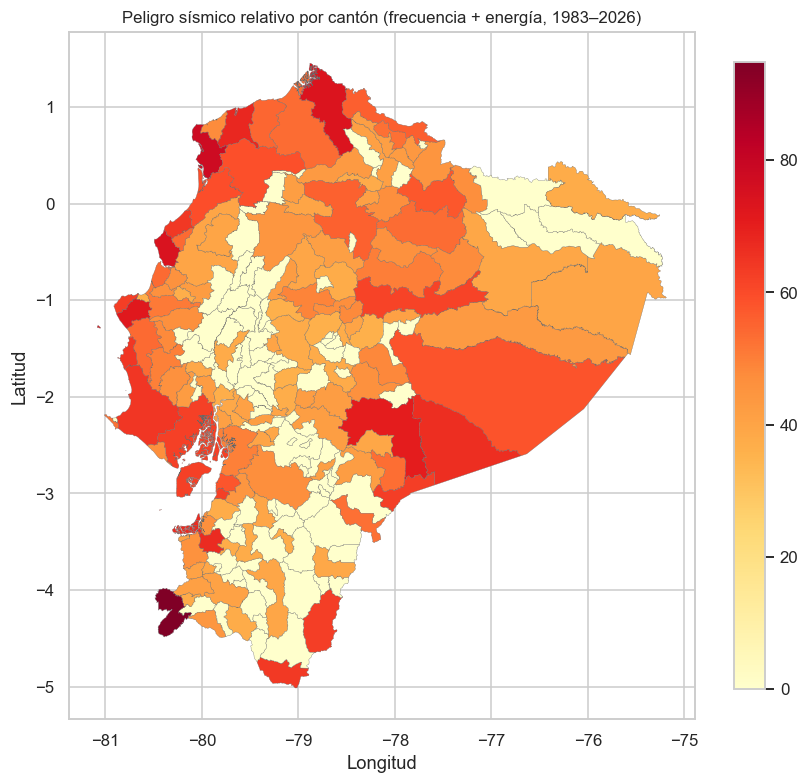

In [11]:
fig, _ = mapa_canton(base, "indice_peligro",
                     "Peligro sísmico relativo por cantón (frecuencia + energía, 1983–2026)")
plt.savefig(FIG / "04_mapa_peligro.png", bbox_inches="tight")
plt.show()

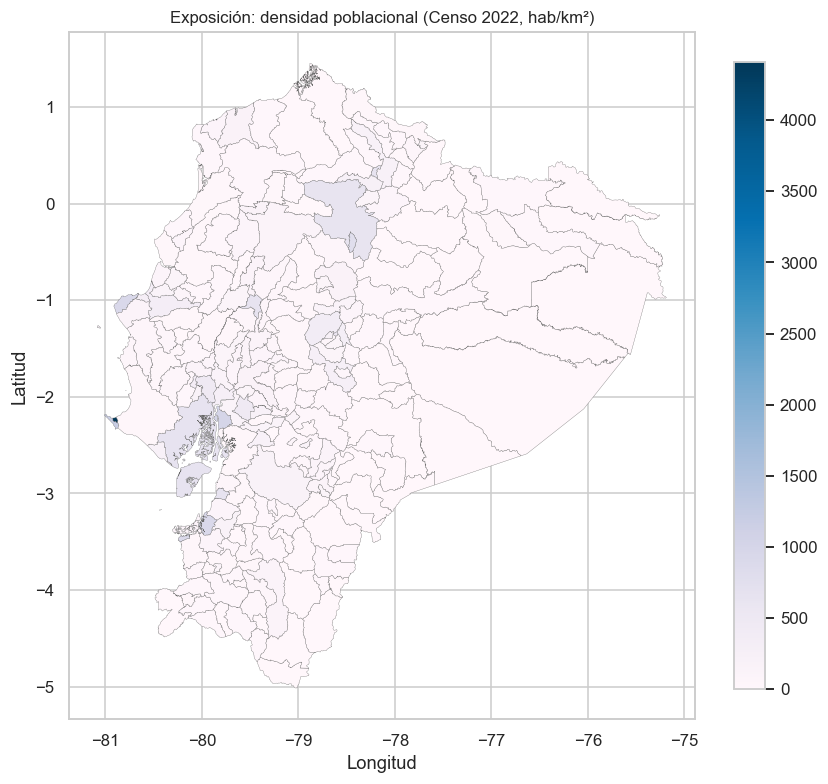

In [12]:
fig, _ = mapa_canton(base, "densidad_hab_km2",
                     "Exposición: densidad poblacional (Censo 2022, hab/km²)", cmap="PuBu")
plt.savefig(FIG / "04_mapa_exposicion.png", bbox_inches="tight")
plt.show()

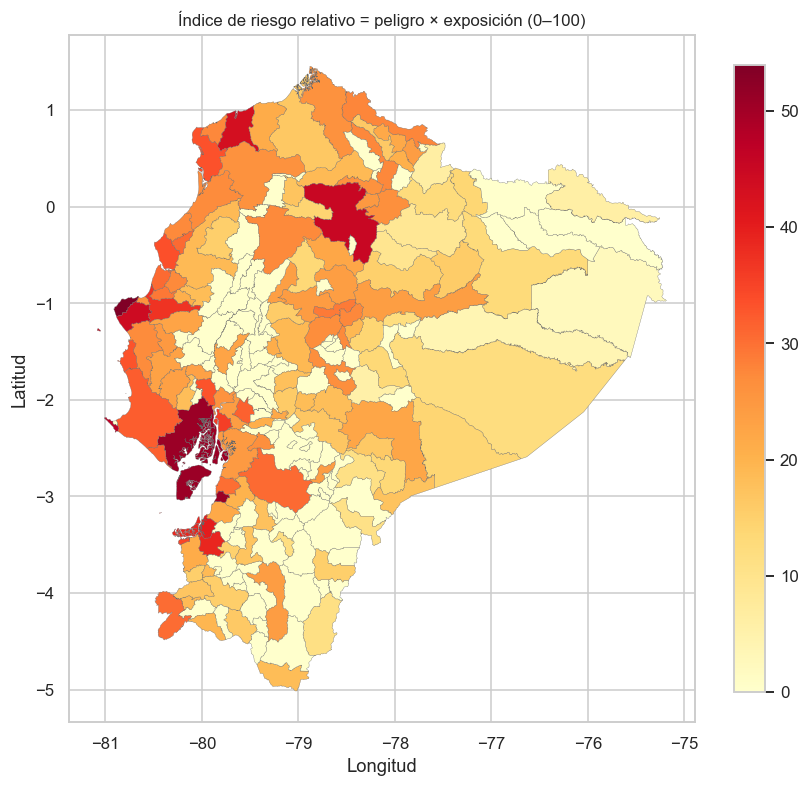

In [13]:
fig, _ = mapa_canton(base, "indice_riesgo",
                     "Índice de riesgo relativo = peligro × exposición (0–100)")
plt.savefig(FIG / "04_mapa_riesgo.png", bbox_inches="tight")
plt.show()

**Lectura de los mapas:**
- El **peligro** se concentra en la franja costera de Manabí–Esmeraldas
  (interfaz de subducción) y en sectores de la Amazonía occidental
  (sismicidad profunda) y suroccidente (fallamiento cortical).
- La **exposición** concentra la densidad en el eje Quito–Guayaquil y cabeceras
  cantonales de la Sierra.
- El **riesgo relativo** emerge donde ambos factores coinciden: la costa
  centro-norte manabita y cantones del litoral con cabecera densa.

C:\Users\Jordan\AppData\Local\Temp\ipykernel_12504\236797682.py:13: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Jordan\AppData\Local\Temp\ipykernel_12504\236797682.py:13: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Jordan\AppData\Local\Temp\ipykernel_12504\236797682.py:14: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(FIG / "04_peligro_vs_exposicion.png", bbox_inches="tight")
C:\Users\Jordan\AppData\Local\Temp\ipykernel_12504\236797682.py:14: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(FIG / "04_peligro_vs_exposicion.png", bbox_inches="tight")


C:\Users\Jordan\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Jordan\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


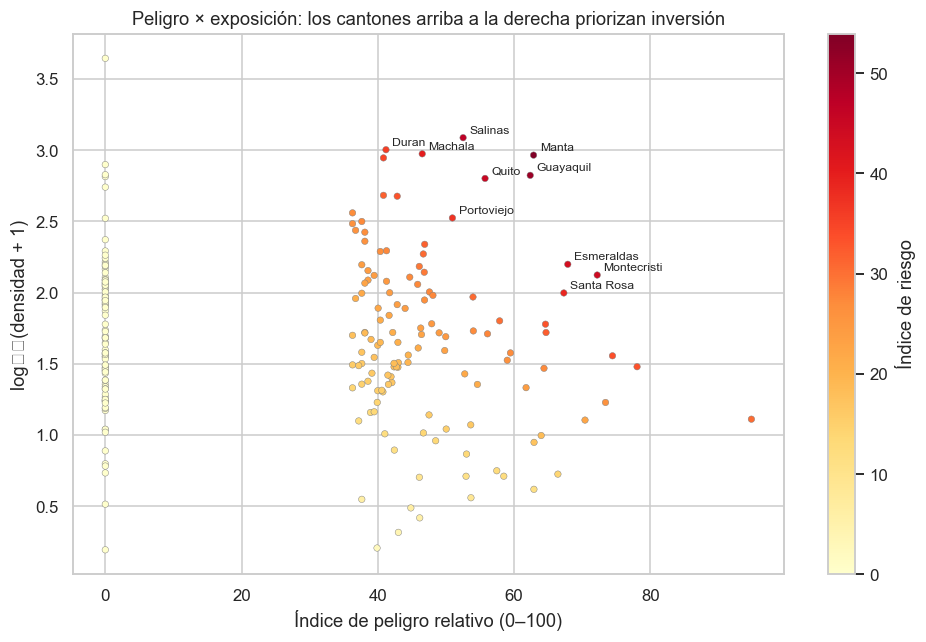

In [14]:
# --- Figura: peligro vs exposición con los cantones destacados ---
fig, eje = plt.subplots(figsize=(9, 6))
con_datos = base[(base["poblacion_2022"] > 0)]
eje.scatter(con_datos["indice_peligro"], np.log10(con_datos["densidad_hab_km2"] + 1),
            s=18, c=con_datos["indice_riesgo"], cmap="YlOrRd", edgecolor="grey", lw=0.3)
for _, fila in base.nlargest(10, "indice_riesgo").iterrows():
    eje.annotate(fila["canton"], (fila["indice_peligro"], np.log10(fila["densidad_hab_km2"] + 1)),
                 fontsize=8, xytext=(4, 3), textcoords="offset points")
eje.set_xlabel("Índice de peligro relativo (0–100)")
eje.set_ylabel("log₁₀(densidad + 1)")
eje.set_title("Peligro × exposición: los cantones arriba a la derecha priorizan inversión")
plt.colorbar(eje.collections[0], ax=eje, label="Índice de riesgo")
plt.tight_layout()
plt.savefig(FIG / "04_peligro_vs_exposicion.png", bbox_inches="tight")
plt.show()

In [15]:
# --- Guardamos el dataset final con los índices ---
base.to_file("data/processed/cantones_riesgo.geojson", driver="GeoJSON")
base.drop(columns="geometry").to_csv("data/processed/cantones_indice_riesgo.csv", index=False)
print("[ok] Guardados: cantones_riesgo.geojson y cantones_indice_riesgo.csv")

[ok] Guardados: cantones_riesgo.geojson y cantones_indice_riesgo.csv


## Resumen de la fase 4a

- Se construyó un **índice de riesgo relativo cantonal** transparente y
  reproducible (frecuencia + energía Gutenberg-Richter, y densidad del Censo 2022).
- El índice **ordena territorios** para decisión de inversión; no estima
  probabilidad de excedencia de aceleración (eso exige un análisis PSHA
  completo con tasas de actividad y leyes de atenuación, fuera de alcance).
- En `06_evaluation.ipynb` lo contrastamos cualitativamente con la zonificación
  sísmica de la NEC.